# Importing Libraries

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import *

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    SelectFromModel
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

import joblib

import warnings
warnings.filterwarnings("ignore")

# Loading Preprocessed Artifacts

In [2]:
X_train = joblib.load(
    ARTIFACT_DIR / "X_train_scaled.pkl"
)

X_test = joblib.load(
    ARTIFACT_DIR / "X_test_scaled.pkl"
)

y_train = joblib.load(
    ARTIFACT_DIR / "y_train.pkl"
)

y_test = joblib.load(
    ARTIFACT_DIR / "y_test.pkl"
)

selected_features = joblib.load(
    ARTIFACT_DIR / "selected_features.pkl"
)

print(X_train.shape)

(120, 35192)


# ANOVA F-Test

## Running ANOVA & getting scores

In [10]:
k_values = [50, 100, 250, 500, 1000, 2000]

anova_results = {}

for k in k_values:

    selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector.fit_transform(
        X_train,
        y_train
    )

    selected_indices = selector.get_support(indices=True)

    selected_genes = selected_features[selected_indices]

    scores = selector.scores_[selected_indices]

    selected_df = pd.DataFrame({
        "gene": selected_genes,
        "anova_score": scores
    })

    selected_df = selected_df.sort_values(
        by="anova_score",
        ascending= True
    )

    anova_results[k] = selected_df

    print(f"\nTop genes for k={k}")
    print(selected_df.head(10))


Top genes for k=50
              gene  anova_score
41       229150_at    95.601179
33     215373_x_at    95.810309
49  AFFX-CreX-3_at    95.848987
19       209335_at    96.416236
48     241993_x_at    96.720184
34     218211_s_at    98.007788
35       218542_at    98.189460
45     234762_x_at    98.355959
22       209642_at    98.462833
31     213975_s_at    99.174037

Top genes for k=100
           gene  anova_score
30  208246_x_at    85.583314
81  231825_x_at    85.605271
20  202870_s_at    85.894546
46    213241_at    86.450961
66  223121_s_at    86.503744
75    225834_at    86.506889
51    215269_at    86.528003
48  214707_x_at    86.674756
23    204825_at    86.681595
86    235335_at    86.792686

Top genes for k=250
            gene  anova_score
230    241681_at    67.641722
116  215587_x_at    67.715077
234    242068_at    67.778082
92     212495_at    67.794221
165    224753_at    67.814479
112  215281_x_at    67.982266
55     205394_at    68.072088
222    239969_at    68.2180

In [15]:
anova_selector = SelectKBest( score_func=f_classif, k=250 )
X_train_anova = anova_selector.fit_transform( X_train, y_train )

In [16]:
anova_scores = pd.DataFrame({
    "gene": selected_features,
    "score": anova_selector.scores_
})

anova_scores = anova_scores.sort_values(
    by="score",
    ascending=False
)

anova_scores.head()

,gene,score
12239,211161_s_at,395.305204
4736,201744_s_at,368.636534
15327,215076_s_at,340.865226
12017,210809_s_at,301.795537
4841,201852_x_at,283.302989


## Visualize Top Genes

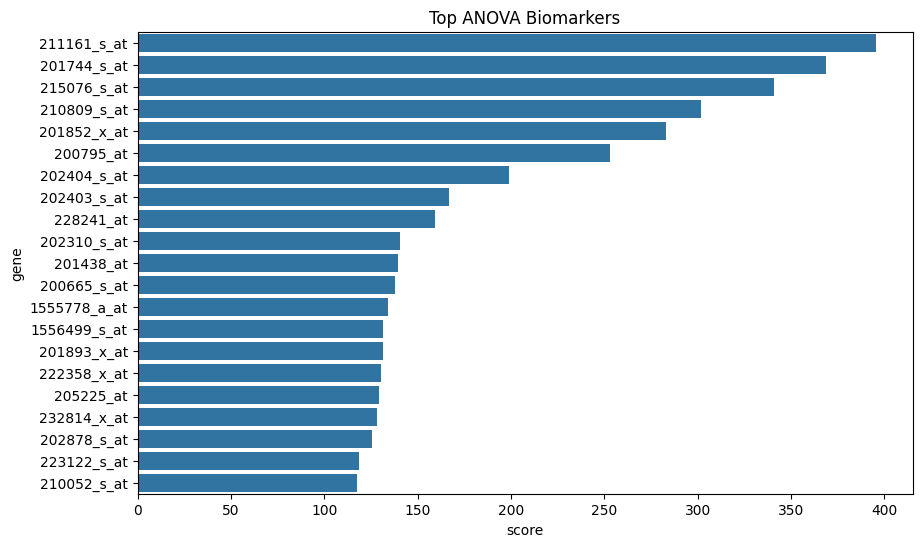

In [19]:
top_anova = anova_scores.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_anova,
    x="score",
    y="gene"
)

plt.title("Top ANOVA Biomarkers")

plt.show()

# Mutual Information Analysis

## Run MI

In [20]:
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

## Build Table

In [21]:
mi_df = pd.DataFrame({
    "gene": selected_features,
    "score": mi_scores
})

mi_df = mi_df.sort_values(
    by="score",
    ascending=False
)

mi_df.head()

,gene,score
12419,211519_s_at,0.932102
10982,209464_at,0.872715
11500,210052_s_at,0.869403
21040,223229_at,0.864874
29053,233868_x_at,0.862588


## Plot

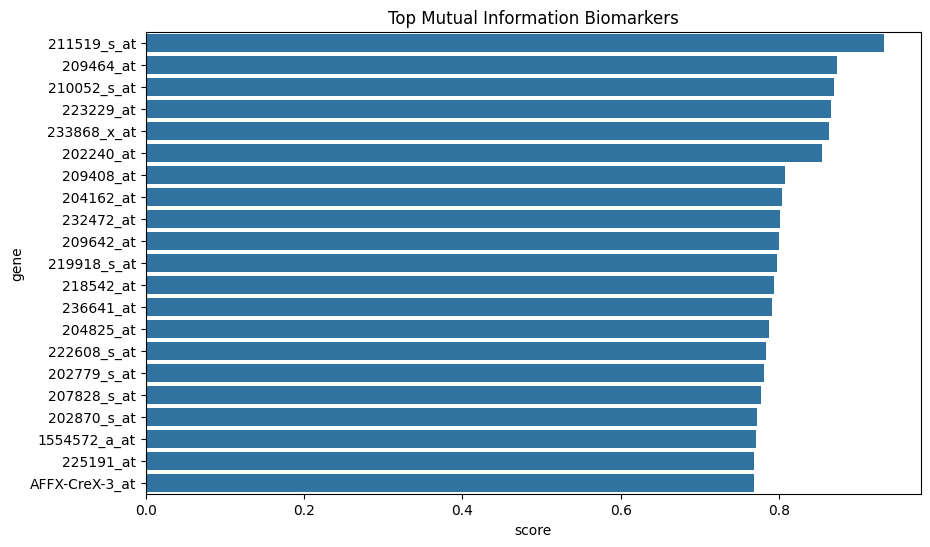

In [22]:
top_mi = mi_df.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_mi,
    x="score",
    y="gene"
)

plt.title("Top Mutual Information Biomarkers")

plt.show()

# Random Forest Feature Importance

## Train RF

In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

## Extract Importance

In [25]:
rf_importance = pd.DataFrame({
    "gene": selected_features,
    "importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="importance",
    ascending=False
)

rf_importance.head()

,gene,importance
35042,55616_at,0.004451
12089,210930_s_at,0.004237
26133,229150_at,0.004151
21117,223307_at,0.003817
387,1553434_at,0.003577


## Plot

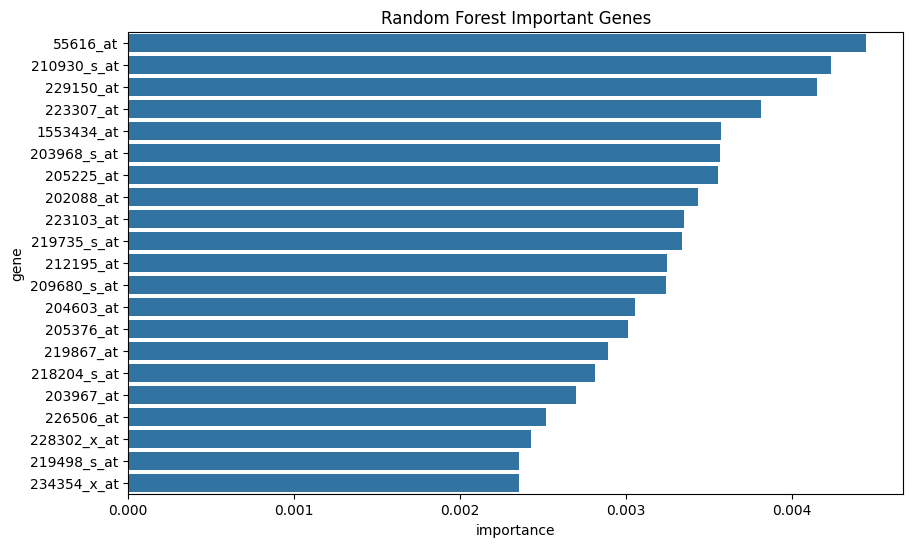

In [26]:
top_rf = rf_importance.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rf,
    x="importance",
    y="gene"
)

plt.title("Random Forest Important Genes")

plt.show()

# LASSO Feature Selection

## Train LASSO Logistic Regression

In [27]:
lasso = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

lasso.fit(X_train, y_train)

LogisticRegression(max_iter=5000, n_jobs=-1, penalty='l1', random_state=42,
                   solver='saga')

## Extract Important Features

In [28]:
lasso_coef = np.abs(lasso.coef_).mean(axis=0)

lasso_importance = pd.DataFrame({
    "gene": selected_features,
    "importance": lasso_coef
})

lasso_importance = lasso_importance.sort_values(
    by="importance",
    ascending=False
)

lasso_importance.head()

,gene,importance
5936,202991_at,0.020758
21860,224447_s_at,0.020481
12089,210930_s_at,0.019833
11988,210761_s_at,0.018935
16220,216836_s_at,0.018016


## Plot

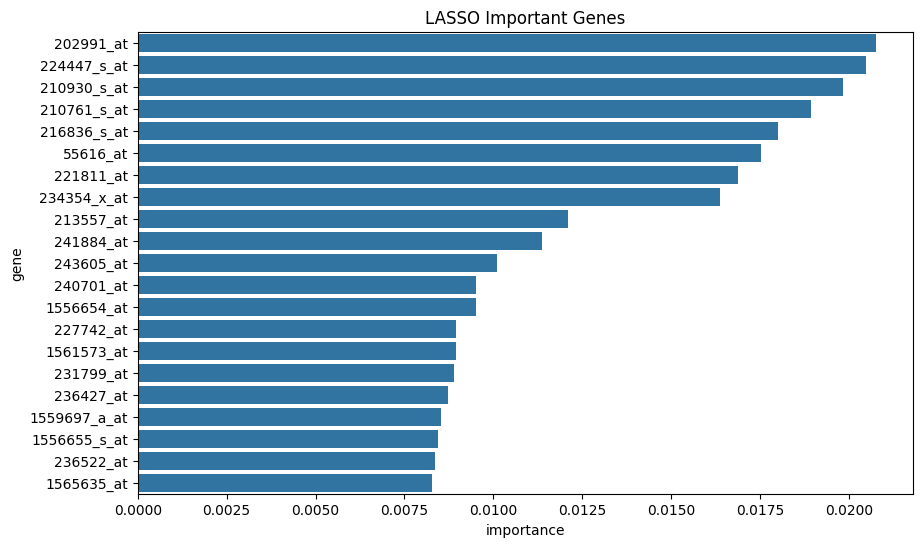

In [29]:
top_lasso = lasso_importance.head(21)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_lasso,
    x="importance",
    y="gene"
)

plt.title("LASSO Important Genes")

plt.show()

# Compare Methods

## Top Genes Per Method

In [30]:
TOP_K = 250

anova_top = set(anova_scores.head(TOP_K)["gene"])
mi_top = set(mi_df.head(TOP_K)["gene"])
rf_top = set(rf_importance.head(TOP_K)["gene"])
lasso_top = set(
    lasso_importance.head(TOP_K)["gene"]
)

from collections import Counter

all_selected = (
    list(anova_top) +
    list(mi_top) +
    list(rf_top) +
    list(lasso_top)
)

gene_counts = Counter(all_selected)

top_consensus = pd.DataFrame(
    gene_counts.items(),
    columns=["gene", "frequency"]
)

top_consensus = top_consensus.sort_values(
    by="frequency",
    ascending=False
)

top_consensus.head(21)

,gene,frequency
8,218211_s_at,4
83,216836_s_at,4
243,AFFX-CreX-5_at,4
48,55616_at,4
53,AFFX-CreX-3_at,4
399,221811_at,3
240,210930_s_at,3
211,206364_at,3
126,218726_at,3
158,1558448_a_at,3


## Common Genes

In [31]:
gene_counts.most_common(21)

[('218211_s_at', 4),
 ('55616_at', 4),
 ('AFFX-CreX-3_at', 4),
 ('216836_s_at', 4),
 ('AFFX-CreX-5_at', 4),
 ('200934_at', 3),
 ('229150_at', 3),
 ('214594_x_at', 3),
 ('236641_at', 3),
 ('209603_at', 3),
 ('218542_at', 3),
 ('205225_at', 3),
 ('225834_at', 3),
 ('228241_at', 3),
 ('209642_at', 3),
 ('1554572_a_at', 3),
 ('200670_at', 3),
 ('218726_at', 3),
 ('224447_s_at', 3),
 ('204603_at', 3)]

# Save Artifacts

## Save score tables

In [32]:
anova_scores.to_parquet(
    ARTIFACT_DIR / "anova_scores.parquet",
    index=False
)

mi_df.to_parquet(
    ARTIFACT_DIR / "mi_scores.parquet",
    index=False
)

rf_importance.to_parquet(
    ARTIFACT_DIR / "rf_importance.parquet",
    index=False
)

lasso_importance.to_parquet(
    ARTIFACT_DIR / "lasso_importance.parquet",
    index=False
)
print('Done')

Done


## Save Consensus Genes

In [33]:
top_consensus.to_parquet(
    ARTIFACT_DIR / "consensus_genes.parquet",
    index=False
)

TOP_CONSENSUS_GENES = top_consensus[
    top_consensus["frequency"] >= 2
]["gene"].tolist()

joblib.dump(
    TOP_CONSENSUS_GENES,
    ARTIFACT_DIR / "top_consensus_genes.pkl"
)

print(f"Stable biomarkers: {len(TOP_CONSENSUS_GENES)}")

Stable biomarkers: 165


## Save Feature Selection Models

In [34]:
joblib.dump(
    anova_selector,
    ARTIFACT_DIR / "anova_selector.pkl"
)

joblib.dump(
    rf,
    ARTIFACT_DIR / "rf_model_fs.pkl"
)

joblib.dump(
    lasso,
    ARTIFACT_DIR / "lasso_model.pkl"
)

['C:\\Jupyter Notebook\\PROJECTS\\Breast_cancer_analysis\\data\\artifacts\\lasso_model.pkl']

In [35]:
methods = {
    "ANOVA": anova_top,
    "MI": mi_top,
    "RF": rf_top,
    "LASSO": lasso_top
}

overlap_matrix = pd.DataFrame(
    index=methods.keys(),
    columns=methods.keys()
)

for m1, g1 in methods.items():
    for m2, g2 in methods.items():
        
        overlap = len(g1 & g2)
        
        overlap_matrix.loc[m1, m2] = overlap

overlap_matrix

,ANOVA,MI,RF,LASSO
ANOVA,250,89,37,20
MI,89,250,63,14
RF,37,63,250,31
LASSO,20,14,31,250


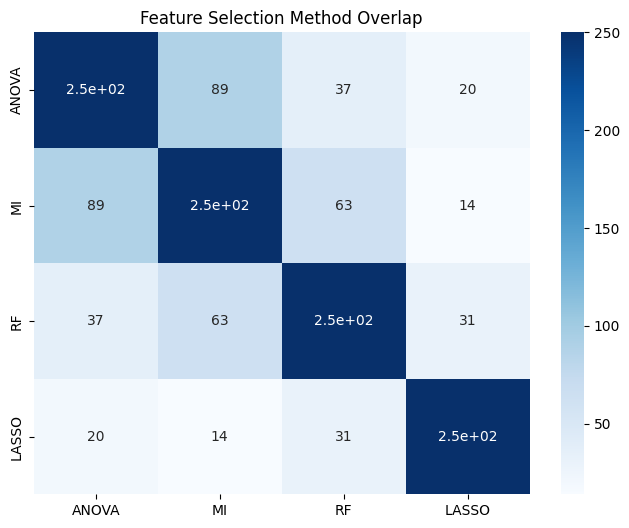

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    overlap_matrix.astype(int),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Selection Method Overlap")

plt.show()